In [10]:
import pandas as pd

df = pd.read_csv("../../results/week6/proactive_predictions.csv")

false_negatives = df[
    (df["Actual"] == 1) &
    (df["Predicted"] == 0)
]

false_negatives

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Actual,Predicted
9,0,179,90,27,0,44.1,0.686,23,1,1,0
27,1,113,64,35,0,33.6,0.543,21,1,1,0
93,3,112,74,30,0,31.6,0.197,25,1,1,0
100,2,102,86,36,120,45.5,0.127,23,1,1,0
121,5,0,80,32,0,41.0,0.346,37,1,1,0
141,1,133,102,28,140,32.8,0.234,45,1,1,0
169,0,131,66,40,0,34.3,0.196,22,1,1,0
248,2,105,80,45,191,33.7,0.711,29,1,1,0
257,0,135,68,42,250,42.3,0.365,24,1,1,0
274,6,0,68,41,0,39.0,0.727,41,1,1,0


In [11]:
false_negatives.to_csv(
    "../../results/week6/false_negative_patients.csv",
    index=False
)

In [12]:
false_negatives.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,20.0,2.2500,2.881429,0.000,0.0000,2.000,3.000,12.000
Glucose,20.0,123.4500,52.127854,0.000,110.2500,128.500,154.000,197.000
BloodPressure,20.0,78.1000,10.750275,64.000,69.5000,77.000,87.000,102.000
SkinThickness,20.0,34.7000,19.120394,0.000,26.7500,31.500,41.250,99.000
Insulin,20.0,79.5500,87.994303,0.000,0.0000,45.000,157.500,250.000
BMI,20.0,36.5250,4.841691,29.700,32.7000,34.500,41.275,45.500
DiabetesPedigreeFunction,20.0,0.4526,0.235697,0.127,0.2595,0.368,0.683,0.968
Age,20.0,30.8500,10.864113,21.000,22.7500,27.500,35.500,62.000
Outcome,20.0,1.0000,0.000000,1.000,1.0000,1.000,1.000,1.000
Actual,20.0,1.0000,0.000000,1.000,1.0000,1.000,1.000,1.000


In [13]:
diabetic = df[df["Actual"] == 1]

comparison = pd.DataFrame({
    "False Negative Mean": false_negatives.mean(numeric_only=True),
    "All Diabetic Mean": diabetic.mean(numeric_only=True)
})

comparison

,False Negative Mean,All Diabetic Mean
Pregnancies,2.2500,4.419355
Glucose,123.4500,141.596774
BloodPressure,78.1000,68.588710
SkinThickness,34.7000,22.137097
Insulin,79.5500,99.290323
BMI,36.5250,35.171774
DiabetesPedigreeFunction,0.4526,0.570177
Age,30.8500,35.935484
Outcome,1.0000,1.000000
Actual,1.0000,1.000000


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../results/week6/proactive_predictions.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (380, 11)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            4      197             70             39      744  36.7   
1            0      117             80             31       53  45.2   
2            4      142             86              0        0  44.0   
3            6      134             80             37      370  46.2   
4            1       79             80             25       37  25.4   

   DiabetesPedigreeFunction  Age  Outcome  Actual  Predicted  
0                     2.329   31        0       0          1  
1                     0.089   24        0       0          0  
2                     0.645   22        1       1          1  
3                     0.238   46        1       1          1  
4                     0.583   22        0       0          0  


In [15]:
print("="*50)
print("Prediction Summary")
print("="*50)

print("Total Samples:", len(df))
print("Actual Diabetic Patients:", (df["Actual"] == 1).sum())
print("Predicted Diabetic Patients:", (df["Predicted"] == 1).sum())


Prediction Summary
Total Samples: 380
Actual Diabetic Patients: 124
Predicted Diabetic Patients: 217


In [16]:
tp = df[(df["Actual"] == 1) & (df["Predicted"] == 1)]
fn = df[(df["Actual"] == 1) & (df["Predicted"] == 0)]
fp = df[(df["Actual"] == 0) & (df["Predicted"] == 1)]
tn = df[(df["Actual"] == 0) & (df["Predicted"] == 0)]

print("True Positives :", len(tp))
print("False Negatives:", len(fn))
print("False Positives:", len(fp))
print("True Negatives :", len(tn))

True Positives : 104
False Negatives: 20
False Positives: 113
True Negatives : 143


In [17]:
features = [
    "Glucose",
    "BMI",
    "Age",
    "Insulin",
    "BloodPressure",
    "Pregnancies"
]

comparison = pd.DataFrame({
    "True Positive Mean": tp[features].mean(),
    "False Negative Mean": fn[features].mean()
})

comparison["Difference"] = (
    comparison["False Negative Mean"] -
    comparison["True Positive Mean"]
)

print(comparison.round(2))

               True Positive Mean  False Negative Mean  Difference
Glucose                    145.09               123.45      -21.64
BMI                         34.91                36.52        1.61
Age                         36.91                30.85       -6.06
Insulin                    103.09                79.55      -23.54
BloodPressure               66.76                78.10       11.34
Pregnancies                  4.84                 2.25       -2.59


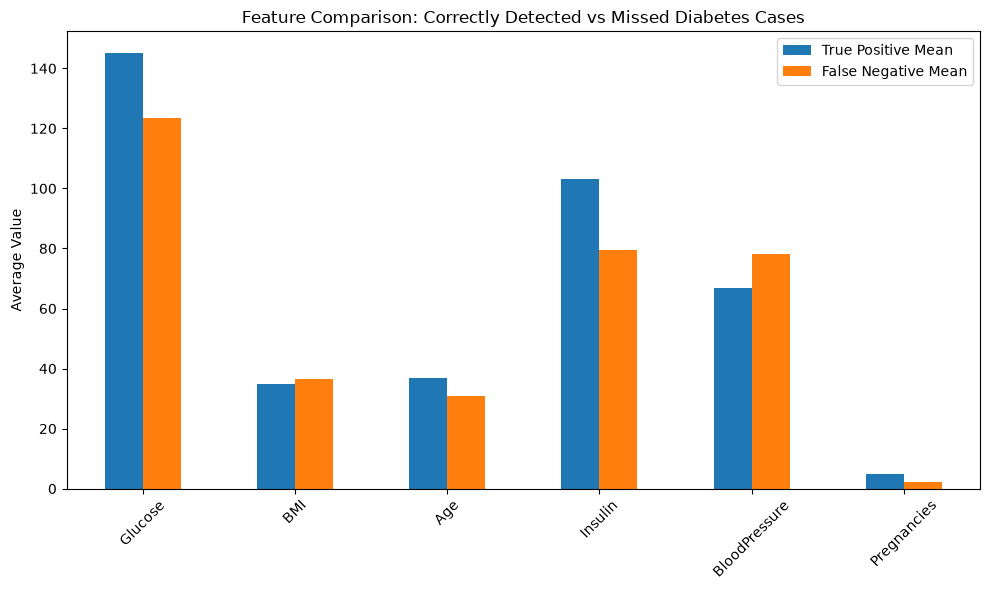

In [18]:
comparison[["True Positive Mean","False Negative Mean"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Feature Comparison: Correctly Detected vs Missed Diabetes Cases")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../../results/week6/error_analysis_feature_comparison.png")
plt.show()